In [1]:
from moscot.problems.time import TemporalProblem
import cellrank as cr
import scanpy as sc
from cellrank.kernels import RealTimeKernel

import numpy as np
import re
import scipy
import json
from datetime import datetime

In [2]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

In [3]:
adata = sc.read_h5ad('gut_data/gut_hs_fetal_epithelial_scVI_AM_06032025_145649_raw.h5ad')

In [4]:
adata.obs['full_age'].value_counts()

full_age
10.3 week    11863
14.4 week     8010
11.9 week     6597
8.4 week      6159
11.2 week     6082
12.2 week     5399
17.4 week     4914
15 week       4506
18.9 week     3236
9.9 week      2860
11.4 week     2191
6.7 week      2152
18.1 week     1910
8.7 week      1835
8.9 week      1402
10.4 week     1030
12 week        765
16 week        456
8.1 week       179
17 week        166
Name: count, dtype: int64

In [5]:
def extract_age(age_string):
    match = re.search(r'(\d+\.?\d*)', str(age_string))
    if match:
        return float(match.group(1))
    else:
        return np.nan

In [6]:
adata.obs['age_numeric'] = adata.obs['full_age'].apply(extract_age)

In [7]:
adata.obs["age_numeric"] = adata.obs["age_numeric"].astype(float)

In [8]:
adata.obs['cell_states'] = adata.obs['cell_states'].astype('str') + '_' + adata.obs['leiden_cluster'].astype('str')
adata.obs['cell_states'] = adata.obs['cell_states'].str.replace(r'_nan', '', regex=True)
adata.obs['cell_states'] = adata.obs['cell_states'].astype('category')

In [9]:
sc.pp.subsample(adata, fraction=0.25, random_state=0)

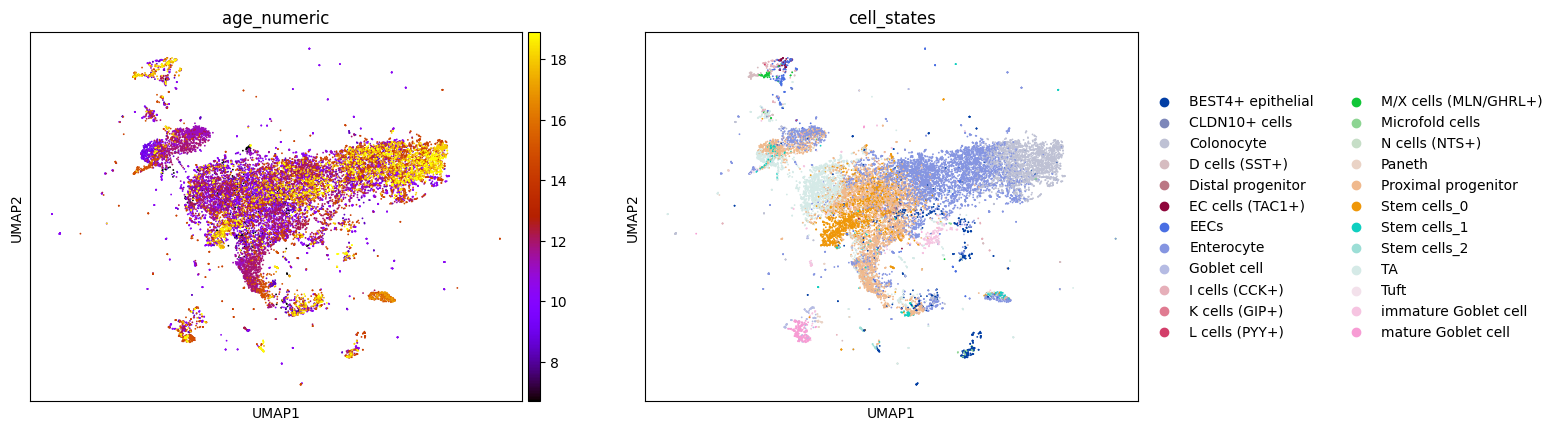

In [10]:
sc.pl.umap(
    adata,
    color=["age_numeric", "cell_states"],
    color_map="gnuplot",
)

## Preprocess the data

In [11]:
if not np.issubdtype(adata.X.dtype, np.floating):
    # If X is a sparse matrix
    if scipy.sparse.issparse(adata.X):
        adata.X = adata.X.astype(np.float32)
    else:
        adata.X = adata.X.astype(np.float32)

In [12]:
sc.pp.pca(adata)
sc.pp.neighbors(adata, random_state=0)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Run moscot to couple cells

In [13]:
tp = TemporalProblem(adata)

In [14]:
tp = tp.score_genes_for_marginals(
    gene_set_proliferation="human", gene_set_apoptosis="human"
)

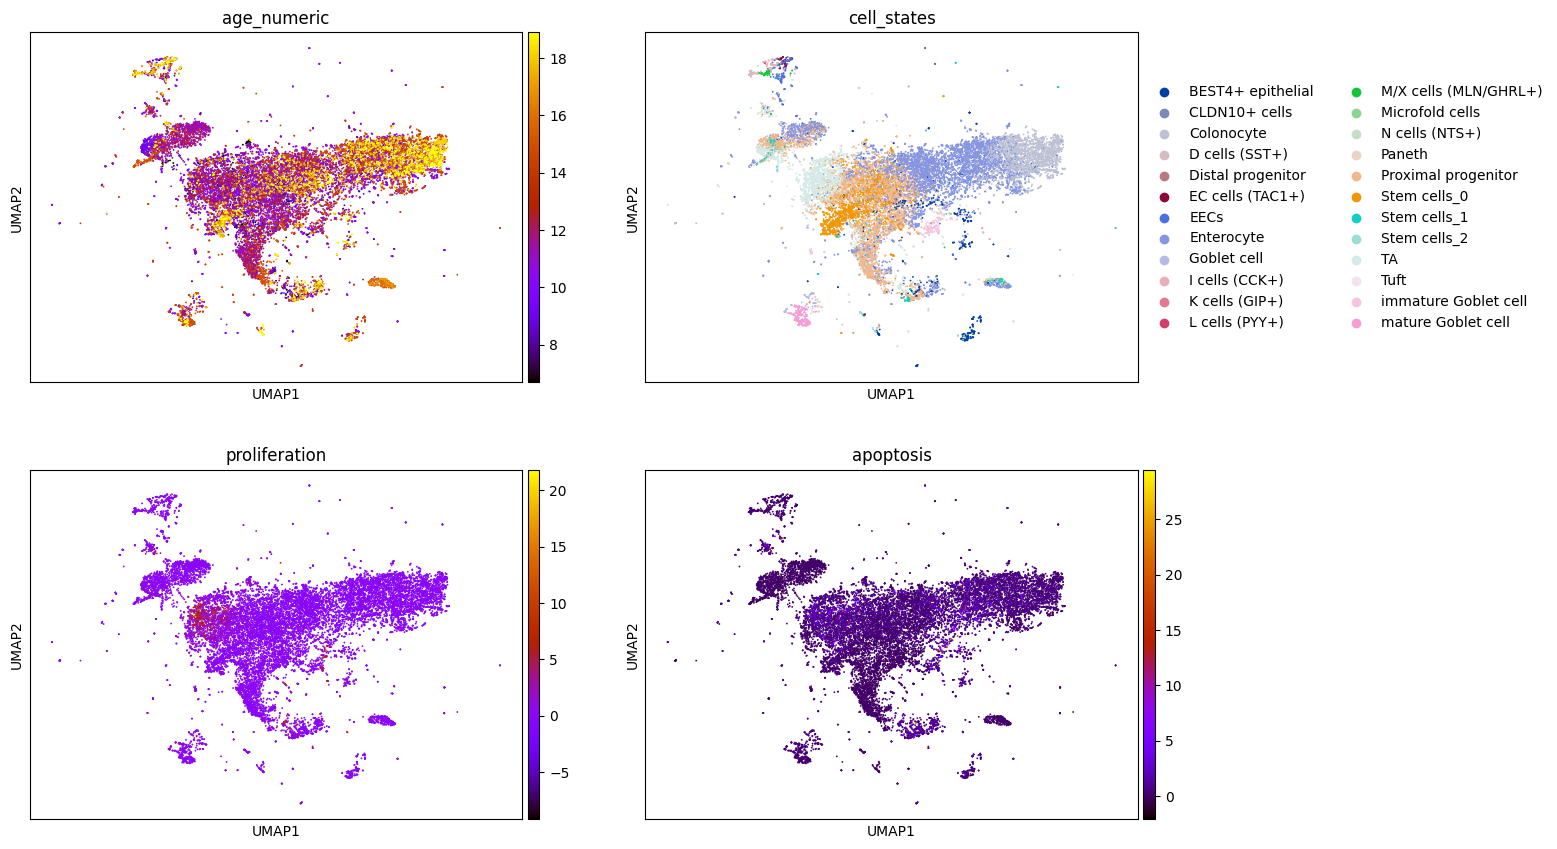

In [15]:
sc.pl.umap(
    adata,
    color=["age_numeric", "cell_states", "proliferation", "apoptosis"],
    color_map="gnuplot",
    ncols=2,
)

In [16]:
tp = tp.prepare(time_key="age_numeric")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`       

In [17]:
tp = tp.solve(epsilon=1e-3, tau_a=0.95, scale_cost="mean")

INFO     Solving `19` problems                                                                                     
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(484, 832)].                                    
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(41, 1515)].                                    
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1492, 550)].                                   
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(716, 3036)].                                   
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(458, 373)].                                    
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(3036, 267)].                                   
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1169, 484)].                                   
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(196,

## Set up the RealTimeKernel

In [18]:
from cellrank.kernels import RealTimeKernel
tmk = RealTimeKernel.from_moscot(tp)

In [19]:
tmk.compute_transition_matrix(self_transitions="all", conn_weight=0.2, threshold="auto")

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 121666.83time pair/s]


RealTimeKernel[n=17928, threshold='auto', self_transitions='all']

## Visualize the recovered dynamics

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:08<00:00, 12.29sim/s]


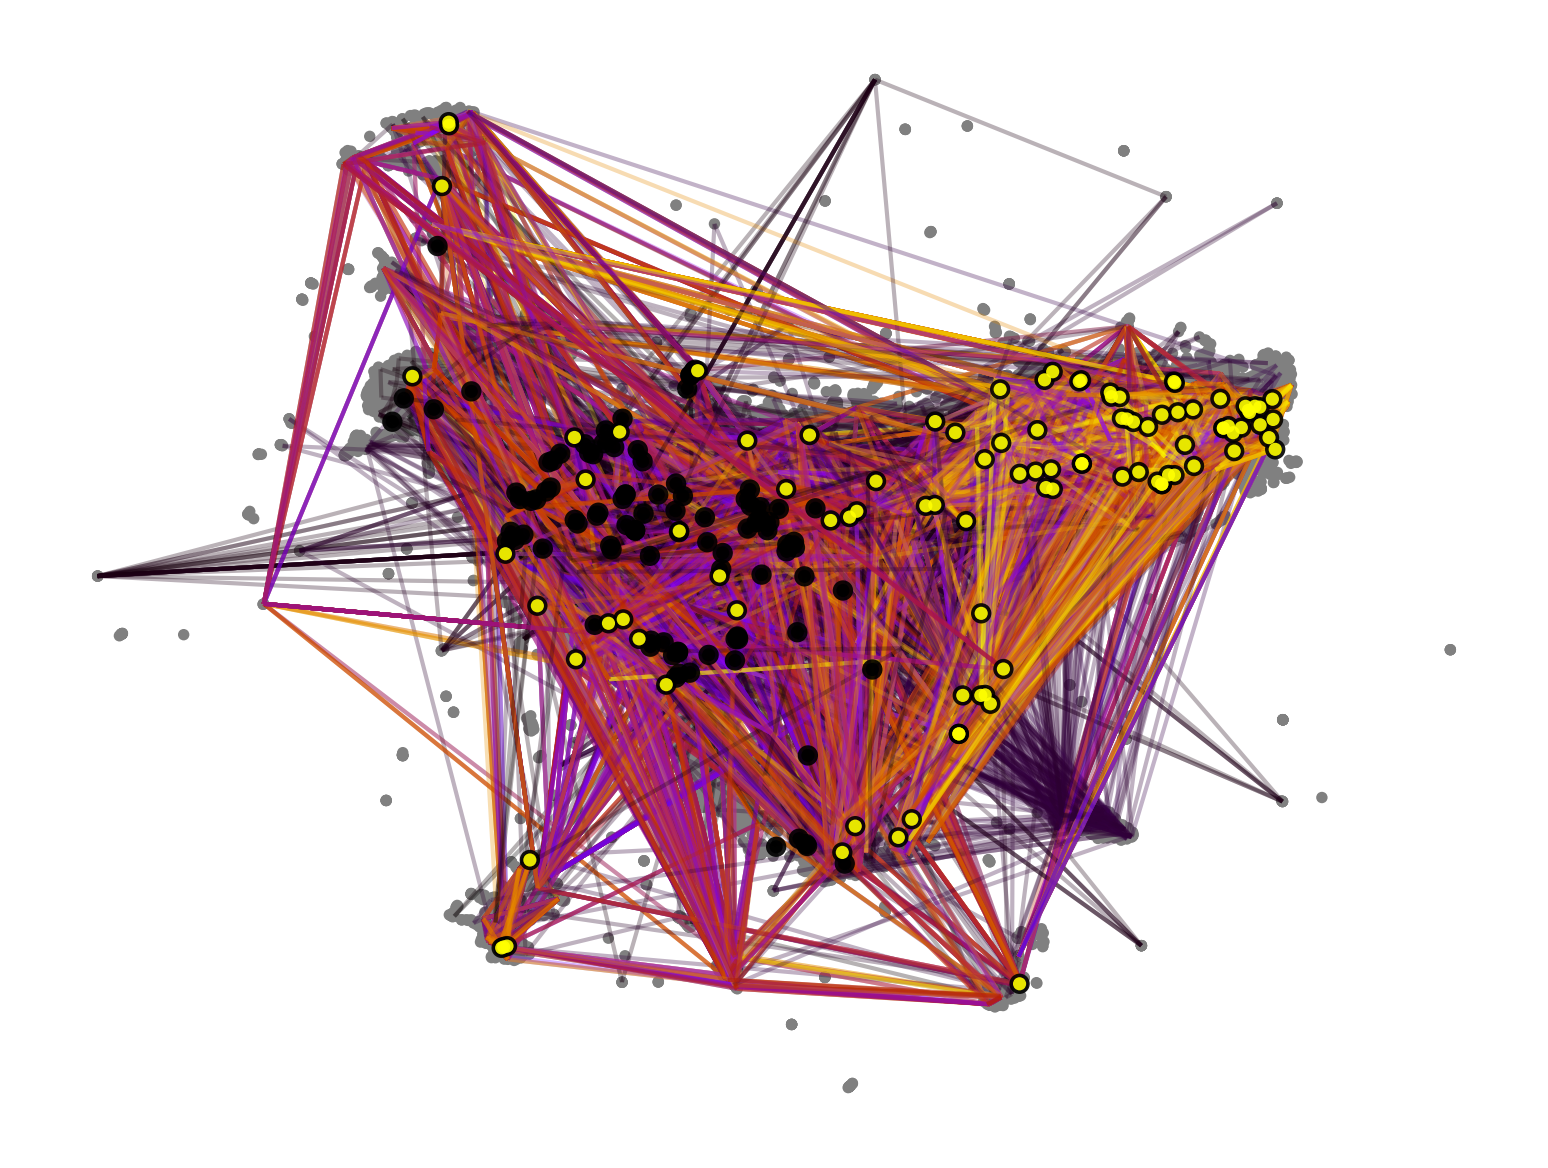

In [34]:
tmk.plot_random_walks(
    max_iter=500,
    start_ixs={"age_numeric": 6.7},
    seed=0,
    size=30,
    save="figures/experimntal_time_random_walk_week6_7_start.png",
    dpi= 300
)

In [ ]:
tmk.plot_random_walks(
    max_iter=500,
    start_ixs={"cell_states": "Stem cells_0"},
    seed=0,
    size=30,
    save="figures/experimntal_time_random_walk_sc0_start.png",
    dpi= 300
)

In [ ]:
tmk.plot_random_walks(
    max_iter=500,
    start_ixs={"cell_states": "Stem cells_1"},
    seed=0,
    size=30,
    save="figures/experimntal_time_random_walk_sc1_start.png",
    dpi= 300
)

In [ ]:
tmk.plot_random_walks(
    max_iter=500,
    start_ixs={"cell_states": "Stem cells_2"},
    seed=0,
    size=30,
    save="figures/experimntal_time_random_walk_sc2_start.png",
    dpi= 300
)

In [ ]:
ax = tmk.plot_single_flow(
    cluster_key="cell_states",
    time_key="age_numeric",
    cluster="Stem cells_0",
    min_flow=0.1,
    xticks_step_size=4,
    show=False,
    save="figures/experimntal_time_flow_chart_SC0.png",
    dpi= 300
)

_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

In [ ]:
ax = tmk.plot_single_flow(
    cluster_key="cell_states",
    time_key="age_numeric",
    cluster="Stem cells_1",
    min_flow=0.1,
    xticks_step_size=4,
    show=False,
    save="figures/experimntal_time_flow_chart_SC1.png",
    dpi= 300
)

_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

In [ ]:
ax = tmk.plot_single_flow(
    cluster_key="cell_states",
    time_key="age_numeric",
    cluster="Stem cells_2",
    min_flow=0.1,
    xticks_step_size=4,
    show=False,
    save="figures/experimntal_time_flow_chart_SC2.png",
    dpi= 300
)

_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

In [ ]:
ax = tmk.plot_single_flow(
    cluster_key="cell_states",
    time_key="age_numeric",
    cluster="immature Goblet cell",
    min_flow=0.1,
    xticks_step_size=4,
    show=False,
    save="figures/experimntal_time_flow_chart_immature_Goblet.png",
    dpi= 300
)

_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

In [ ]:
ax = tmk.plot_single_flow(
    cluster_key="cell_states",
    time_key="age_numeric",
    cluster="Proximal progenitor",
    min_flow=0.1,
    xticks_step_size=4,
    show=False,
    save="figures/experimntal_time_flow_chart_proximal_progenitor.png",
    dpi= 300
)

_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

In [ ]:
ax = tmk.plot_single_flow(
    cluster_key="cell_states",
    time_key="age_numeric",
    cluster="Distal progenitor",
    min_flow=0.1,
    xticks_step_size=4,
    show=False,
    save="figures/experimntal_time_flow_chart_distal_progenitor.png",
    dpi= 300
)

_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)